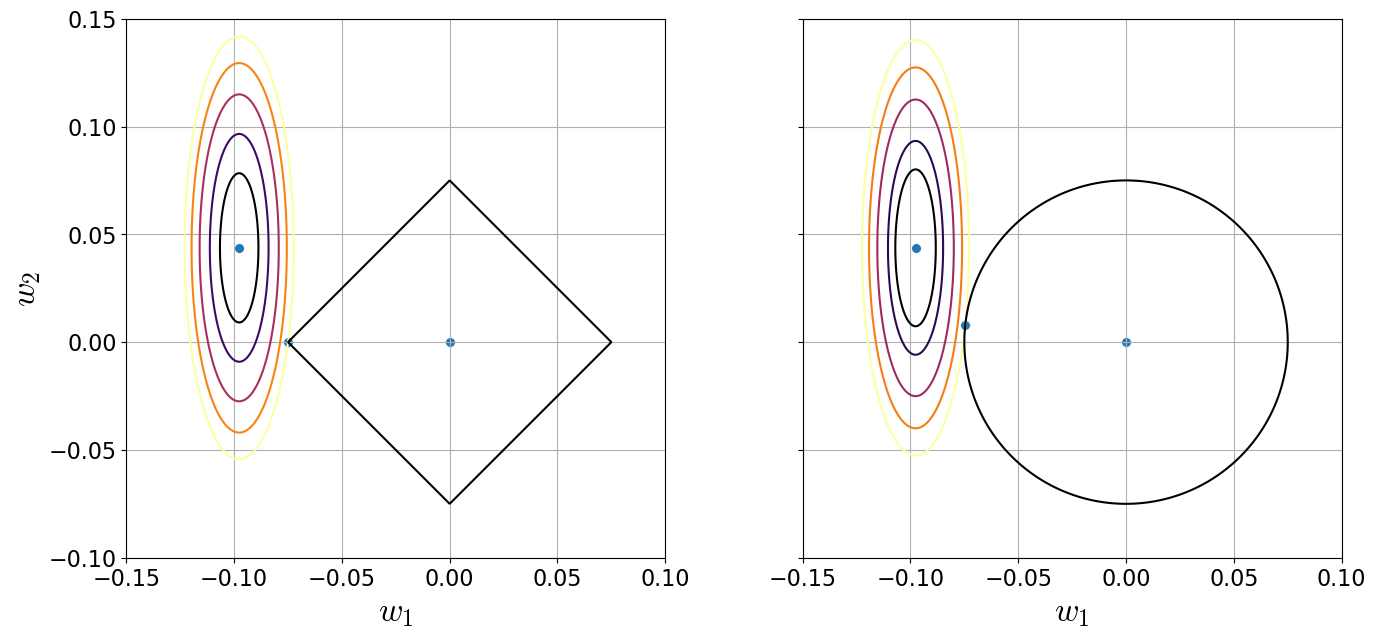

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA


def grid(func, *args):  # 计算格点上的函数值 用于后续画等高线或热力图
    x_min, x_max, y_min, y_max = args
    grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))
    grid_z = func(np.column_stack((grid_x.ravel(), grid_y.ravel())))
    grid_z = grid_z.reshape(grid_x.shape)
    return grid_x, grid_y, grid_z


def cost_func(X, y, w):  # 最小二乘 平方损失
    res = X @ w - y.reshape(-1, 1)  # w可以是2x*的矩阵 y随其广播
    return np.sum(res**2, axis=0)


X = np.array([
    [1., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1.],
    [6., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0.],
    [10., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0.],
    [13., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1.],
])
X = PCA(n_components=2).fit_transform(X)  # 降维到2维
y = np.array([1, 1, 0, 0])
ellipse_center = np.linalg.inv(X.T @ X) @ X.T @ y  # 椭圆中心

x_min, x_max, y_min, y_max = -0.15, 0.1, -0.1, 0.15
grid_x, grid_y, grid_z_l1 = grid(lambda m: np.sum(np.abs(m), axis=1), x_min, x_max, y_min, y_max)
_, _, grid_z_l2 = grid(lambda m: np.sum(m**2, axis=1), x_min, x_max, y_min, y_max)
_, _, grid_z_ls = grid(lambda w: cost_func(X, y, w.T), x_min, x_max, y_min, y_max)

plt.rcParams.update({
    "axes.unicode_minus": True,
    "mathtext.fontset": 'cm',
    "axes.grid": True,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    'axes.labelsize': 24,
})

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(16, 7))

v = cost_func(X, y, np.array([-0.075, 0]).reshape(-1, 1))[0]
ax[0].contour(grid_x, grid_y, grid_z_ls, levels=v * np.array([0.963, 0.97, 0.98, 0.99, 1]), cmap='inferno')
ax[0].contour(grid_x, grid_y, grid_z_l1, levels=[0.075], cmap='inferno')
sns.scatterplot(x=[0, -0.075, ellipse_center[0]], y=[0, 0, ellipse_center[1]], s=50, ax=ax[0])
ax[0].set(xlabel="$w_1$", ylabel="$w_2$", aspect='equal')

for theta in np.linspace(0, np.pi / 2, 1000):  # 遍历圆弧找切点
    w = np.array([- 0.075 * np.cos(theta), 0.075 * np.sin(theta)])
    g = X.T @ X @ w - X.T @ y
    cross_product = np.cross(np.append(w, 0), np.append(g, 0))
    if np.abs(cross_product[2]) < 1e-4:  # 叉乘为零则两个梯度平行
        break

v = cost_func(X, y, w.reshape(-1, 1))[0]
ax[1].contour(grid_x, grid_y, grid_z_ls, levels=v * np.array([0.965, 0.97, 0.98, 0.99, 1]), cmap='inferno')
ax[1].contour(grid_x, grid_y, grid_z_l2, levels=[0.075**2], cmap='inferno')
sns.scatterplot(x=[0, w[0], ellipse_center[0]], y=[0, w[1], ellipse_center[1]], s=50, ax=ax[1])
ax[1].set(xlabel="$w_1$", aspect='equal')

plt.show()